#Problem 1:

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import statsmodels.api as sm

In [3]:
start = "2024-01-04"
end   = "2026-07-18"      # July 17 inclusive

tickers = ["NVDA", "GS", "^OEX"]

prices = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  3 of 3 completed


Ticker,GS,NVDA,^OEX
Date,,,
2024-01-04,362.897369,47.912838,2199.620117
2024-01-05,366.204559,49.009884,2204.560059
2024-01-08,368.497833,52.160286,2238.570068
2024-01-09,363.645905,53.045715,2238.110107
2024-01-10,361.959106,54.253571,2253.280029


In [4]:
prices.info()
prices.tail()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 635 entries, 2024-01-04 to 2026-07-17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GS      635 non-null    float64
 1   NVDA    635 non-null    float64
 2   ^OEX    635 non-null    float64
dtypes: float64(3)
memory usage: 19.8 KB


Ticker,GS,NVDA,^OEX
Date,,,
2026-07-13,1045.910034,203.529999,3696.580078
2026-07-14,1140.000000,211.800003,3710.510010
2026-07-15,1152.069946,212.500000,3743.610107
2026-07-16,1095.459961,207.399994,3717.229980
2026-07-17,1065.219971,202.809998,3674.000000


In [5]:
returns = prices.pct_change().dropna()

returns.columns = ["GS","NVDA","OEX"] if list(returns.columns)==["GS","NVDA","^OEX"] else returns.columns

returns.head()

,GS,NVDA,OEX
Date,,,
2024-01-05,0.009113,0.022897,0.002246
2024-01-08,0.006262,0.064281,0.015427
2024-01-09,-0.013167,0.016975,-0.000205
2024-01-10,-0.004639,0.022770,0.006778
2024-01-11,-0.005786,0.008684,-0.000586


In [6]:
returns.describe()

,GS,NVDA,OEX
count,634.000000,634.000000,634.000000
mean,0.001880,0.002747,0.000864
std,0.019078,0.030691,0.010521
min,-0.092115,-0.169682,-0.059457
25%,-0.007753,-0.014001,-0.003640
50%,0.001496,0.002781,0.001237
75%,0.011709,0.019732,0.006467
max,0.130977,0.187228,0.102015


In [7]:
summary = pd.DataFrame(index=["NVDA","GS"])

summary["Mean Daily Return"] = returns[["NVDA","GS"]].mean()

summary["Daily Volatility"] = returns[["NVDA","GS"]].std()

summary["Annual Return"] = summary["Mean Daily Return"] * 252

summary["Annual Volatility"] = summary["Daily Volatility"] * np.sqrt(252)

summary

,Mean Daily Return,Daily Volatility,Annual Return,Annual Volatility
NVDA,0.002747,0.030691,0.692263,0.487204
GS,0.001880,0.019078,0.473881,0.302851


In [8]:
def calculate_beta(stock, market):

    X = sm.add_constant(market)

    model = sm.OLS(stock, X).fit()

    return model

In [9]:
nvda_model = calculate_beta(
    returns["NVDA"],
    returns["OEX"]
)

gs_model = calculate_beta(
    returns["GS"],
    returns["OEX"]
)

In [10]:
print("NVDA Beta:", nvda_model.params["OEX"])

print("GS Beta:", gs_model.params["OEX"])

NVDA Beta: 2.120834977546619
GS Beta: 1.2064085671271705


In [21]:
beta_summary = pd.DataFrame({
    "Beta": [
        nvda_model.params["OEX"],
        gs_model.params["OEX"]
    ],
    "R-Squared": [
        nvda_model.rsquared,
        gs_model.rsquared
    ]
}, index=["NVDA", "GS"])

print("NVDA Beta:", nvda_model.params["OEX"])
print("GS Beta:", gs_model.params["OEX"])

beta_summary


NVDA Beta: 2.120834977546619
GS Beta: 1.2064085671271705


,Beta,R-Squared
NVDA,2.120835,0.528599
GS,1.206409,0.442655


In [11]:
returns["Portfolio"] = (
    0.5*returns["NVDA"] +
    0.5*returns["GS"]
)

In [12]:
portfolio_mean = returns["Portfolio"].mean()

portfolio_std = returns["Portfolio"].std()

portfolio_annual_return = portfolio_mean * 252

portfolio_annual_vol = portfolio_std * np.sqrt(252)

print(portfolio_mean)
print(portfolio_std)
print(portfolio_annual_return)
print(portfolio_annual_vol)

0.0023137774810085055
0.02107510277366004
0.5830719252141434
0.33455688476539225


In [13]:
X = sm.add_constant(returns["OEX"])

portfolio_model = sm.OLS(
    returns["Portfolio"],
    X
).fit()

print(portfolio_model.summary())

                            OLS Regression Results                            
Dep. Variable:              Portfolio   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     1405.
Date:                Thu, 06 Aug 2026   Prob (F-statistic):          9.00e-163
Time:                        00:17:48   Log-Likelihood:                 1918.9
No. Observations:                 634   AIC:                            -3834.
Df Residuals:                     632   BIC:                            -3825.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      1.870      0.0

In [20]:
performance = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Portfolio Beta",
        "Alpha",
        "R-Squared"
    ],
    "Value": [
        portfolio_annual_return,
        portfolio_annual_vol,
        portfolio_model.params["OEX"],
        portfolio_model.params["const"],
        portfolio_model.rsquared
    ]
})

performance

,Metric,Value
0,Annual Return,0.583072
1,Annual Volatility,0.334557
2,Portfolio Beta,1.663622
3,Alpha,0.000876
4,R-Squared,0.689769


In [14]:
returns[
    ["NVDA","GS","OEX"]
].corr()

,NVDA,GS,OEX
NVDA,1.000000,0.401988,0.727048
GS,0.401988,1.000000,0.665323
OEX,0.727048,0.665323,1.000000


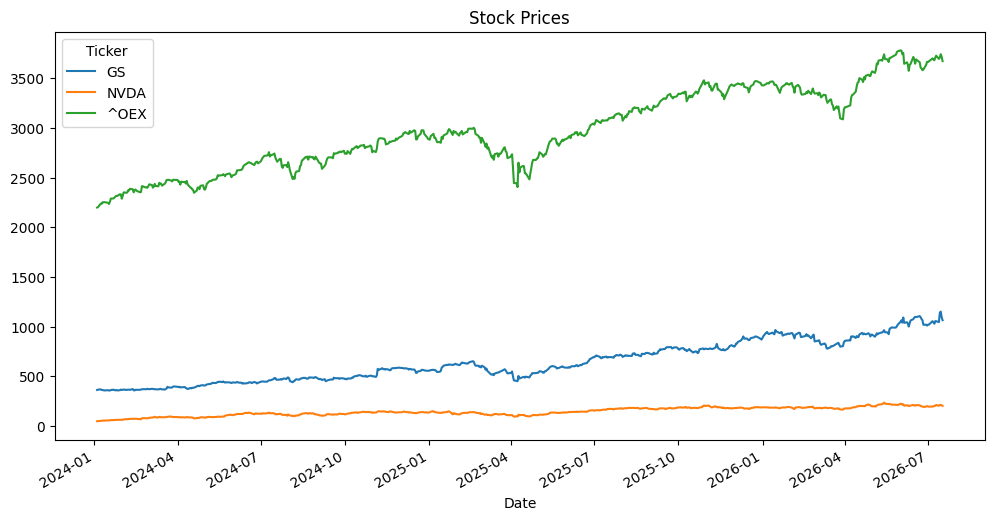

In [15]:
prices.plot(
    figsize=(12,6),
    title="Stock Prices"
)
plt.show()

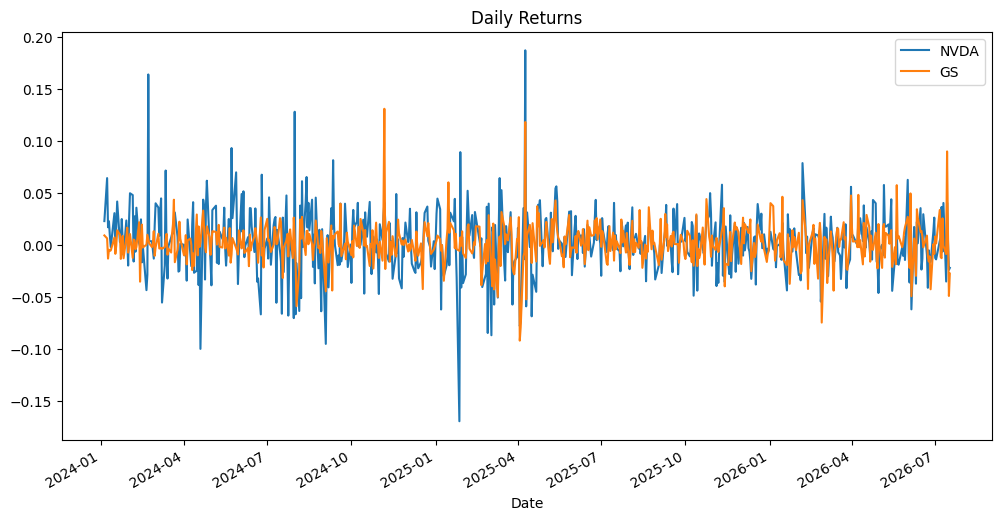

In [16]:
returns[
    ["NVDA","GS"]
].plot(
    figsize=(12,6)
)
plt.title("Daily Returns")
plt.show()

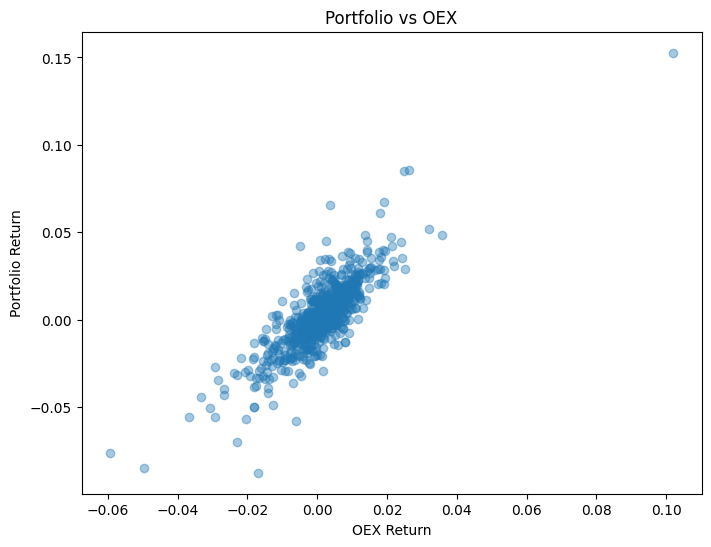

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    returns["OEX"],
    returns["Portfolio"],
    alpha=0.4
)

plt.xlabel("OEX Return")
plt.ylabel("Portfolio Return")

plt.title("Portfolio vs OEX")

plt.show()

# Problem 2:

# Part A

In [22]:
# Total stock volatility
sigma_stock = 0.55

# Factor betas
beta1 = 0.7
beta2 = 1.5

# Factor volatilities
sigma1 = 0.25
sigma2 = 0.14

# Correlation between factors
rho = -0.4

In [23]:
systematic_variance = (
    beta1**2 * sigma1**2
    + beta2**2 * sigma2**2
    + 2 * beta1 * beta2 * rho * sigma1 * sigma2
)

systematic_volatility = np.sqrt(systematic_variance)

print("Systematic Volatility:", systematic_volatility)

Systematic Volatility: 0.2128966885604377


In [24]:
total_variance = sigma_stock**2

In [25]:
specific_variance = total_variance - systematic_variance

specific_volatility = np.sqrt(specific_variance)

print("Specific Volatility:", specific_volatility)

Specific Volatility: 0.507124245131309


In [28]:
partA = pd.DataFrame({
    "Measure": [
        "Total Volatility",
        "Systematic Volatility",
        "Specific Volatility"
    ],
    "Value": [
        sigma_stock,
        systematic_volatility,
        specific_volatility
    ]
})

partA

,Measure,Value
0,Total Volatility,0.550000
1,Systematic Volatility,0.212897
2,Specific Volatility,0.507124


The stock has a total volatility of 55%. The two-factor model explains approximately 21.29% of this volatility as systematic risk, while the remaining 50.71% is attributable to company-specific (idiosyncratic) risk. This indicates that a significant portion of the stock's overall risk is unique to the firm and cannot be explained by the common risk factors alone.

# Part B

In [29]:
weights = np.array([
    -0.20,
     0.70,
     0.50
])

betas = np.array([
    [0.4, 1.7],
    [0.9, 0.5],
    [1.5, 0.4]
])

In [30]:
portfolio_beta = weights @ betas

portfolio_beta

array([1.3 , 0.21])

In [31]:
portfolio_systematic_variance = (
    portfolio_beta[0]**2 * sigma1**2
    + portfolio_beta[1]**2 * sigma2**2
    + 2 * portfolio_beta[0] * portfolio_beta[1] * rho * sigma1 * sigma2
)

portfolio_systematic_volatility = np.sqrt(
    portfolio_systematic_variance
)

print("Portfolio Systematic Volatility:",
      portfolio_systematic_volatility)

Portfolio Systematic Volatility: 0.3143968193223335


In [32]:
partB = pd.DataFrame({
    "Measure": [
        "Portfolio Beta (Factor 1)",
        "Portfolio Beta (Factor 2)",
        "Portfolio Systematic Volatility"
    ],
    "Value": [
        portfolio_beta[0],
        portfolio_beta[1],
        portfolio_systematic_volatility
    ]
})

partB

,Measure,Value
0,Portfolio Beta (Factor 1),1.300000
1,Portfolio Beta (Factor 2),0.210000
2,Portfolio Systematic Volatility,0.314397


The portfolio has a beta of 1.30 with respect to the first risk factor and 0.21 with respect to the second risk factor. Based on these factor exposures, the portfolio's systematic volatility is approximately 31.44%, indicating that the portfolio's exposure is driven primarily by the first risk factor.

# Problem 3:


## Principal Component Analysis (PCA) Risk Model

In [33]:
from sklearn.decomposition import PCA

In [36]:
djia = [
    "AAPL","AMGN","AMZN","AXP","BA","CAT","CRM","CSCO",
    "CVX","DIS","GOOGL","GS","HD","HON","IBM","JNJ",
    "JPM","KO","MCD","MMM","MRK","MSFT","NKE","NVDA",
    "PG","SHW","TRV","UNH","V","WMT"
]

start = "2021-01-04"
end = "2026-07-18"

prices = yf.download(
    djia,
    start=start,
    end=end,
    auto_adjust=True
)["Close"]

[*********************100%***********************]  30 of 30 completed


In [37]:
prices.isna().sum()

,0
Ticker,
AAPL,0
AMGN,0
AMZN,0
AXP,0
BA,0
CAT,0
CRM,0
CSCO,0
CVX,0


In [38]:
returns = prices.pct_change().dropna()

In [39]:
cov_matrix = returns.cov()

cov_matrix.head()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000305,0.000062,0.000207,0.000134,0.000148,0.000092,0.000169,0.000113,0.000055,0.000125,...,0.000038,0.000171,0.000160,0.000278,0.000047,0.000102,0.000051,0.000035,0.000116,0.000062
AMGN,0.000062,0.000225,0.000036,0.000055,0.000044,0.000065,0.000031,0.000048,0.000031,0.000048,...,0.000088,0.000031,0.000061,0.000030,0.000051,0.000066,0.000048,0.000057,0.000049,0.000037
AMZN,0.000207,0.000036,0.000478,0.000171,0.000183,0.000113,0.000250,0.000114,0.000048,0.000171,...,0.000013,0.000227,0.000188,0.000378,0.000022,0.000118,0.000031,0.000035,0.000122,0.000062
AXP,0.000134,0.000055,0.000171,0.000339,0.000195,0.000172,0.000158,0.000109,0.000095,0.000175,...,0.000029,0.000117,0.000160,0.000217,0.000033,0.000116,0.000101,0.000066,0.000150,0.000046
BA,0.000148,0.000044,0.000183,0.000195,0.000530,0.000163,0.000142,0.000086,0.000085,0.000164,...,0.000022,0.000112,0.000163,0.000250,0.000026,0.000103,0.000069,0.000045,0.000102,0.000059


In [40]:
pca = PCA()

pca.fit(returns)

PCA()

In [41]:
eigenvalues = pca.explained_variance_

eigenvalues

array([3.15232288e-03, 9.55419062e-04, 5.47187609e-04, 4.14910166e-04,
       3.98481911e-04, 3.51179014e-04, 3.00519879e-04, 2.93739538e-04,
       2.67086170e-04, 2.44188846e-04, 2.28257038e-04, 1.97732641e-04,
       1.84416402e-04, 1.79039279e-04, 1.63913548e-04, 1.55720708e-04,
       1.44143947e-04, 1.32380908e-04, 1.29244887e-04, 1.22340938e-04,
       1.19642603e-04, 9.82455998e-05, 9.61602957e-05, 8.98417382e-05,
       8.45786455e-05, 7.96202458e-05, 6.41757304e-05, 5.78131976e-05,
       5.66262284e-05, 3.83508619e-05])

In [43]:
eigenvectors = pd.DataFrame(
    pca.components_.T,
    index=returns.columns
)

eigenvectors.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.219720,0.051268,-0.157767,0.050079,-0.075487,0.013385,0.101323,-0.148818,-0.200272,-0.043392,...,-0.128549,-0.156551,0.205316,0.164883,-0.064093,-0.020531,-0.037377,0.064834,0.017951,-0.005874
AMGN,0.079201,-0.181929,-0.146020,-0.163398,-0.165130,-0.003334,-0.009755,-0.131976,-0.134777,-0.228233,...,0.055863,0.045231,0.045030,-0.003632,0.119855,-0.028508,0.089873,-0.107938,0.127325,0.000884
AMZN,0.280266,0.201908,-0.151436,0.199830,0.051152,0.084230,0.450949,-0.010421,-0.058586,0.113562,...,-0.061850,-0.185443,0.022809,0.068097,-0.037473,-0.045834,-0.026183,-0.008722,-0.017244,-0.000194
AXP,0.237322,-0.139114,0.174062,0.005372,0.183992,-0.033733,0.038334,0.107432,0.116545,0.119184,...,0.559526,0.294892,-0.019195,0.246920,-0.360592,-0.019401,-0.076658,0.039152,-0.145322,-0.025334
BA,0.244084,-0.079506,0.336416,0.303777,0.035798,0.690303,-0.274493,-0.363390,-0.057766,-0.002115,...,0.025388,0.006509,0.036230,-0.122125,0.000345,-0.002228,-0.013873,-0.009795,0.037908,0.002665


In [42]:
explained = pd.DataFrame({
    "Principal Component": range(1, len(eigenvalues)+1),
    "Eigenvalue": eigenvalues,
    "Explained Variance (%)": pca.explained_variance_ratio_*100,
    "Cumulative Variance (%)":
        np.cumsum(
            pca.explained_variance_ratio_*100
        )
})

explained

,Principal Component,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,1,0.003152,33.724492,33.724492
1,2,0.000955,10.221359,43.945851
2,3,0.000547,5.853977,49.799827
3,4,0.000415,4.438833,54.238660
4,5,0.000398,4.263079,58.501739
5,6,0.000351,3.757018,62.258757
6,7,0.000301,3.215051,65.473808
7,8,0.000294,3.142513,68.616322
8,9,0.000267,2.857368,71.473689
9,10,0.000244,2.612405,74.086094


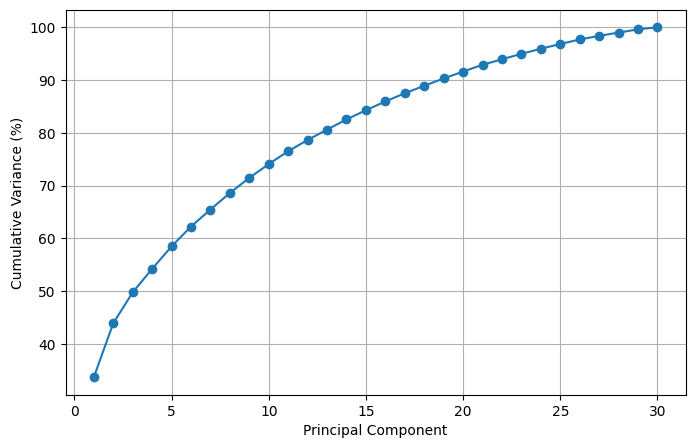

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    explained["Principal Component"],
    explained["Cumulative Variance (%)"],
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance (%)")

plt.grid(True)

plt.show()

The first principal component explains 33.72% of the total variation in returns, indicating that a single common factor accounts for approximately one-third of the co-movement among the 30 DJIA stocks. The first five principal components together explain 58.50% of the total variation, suggesting that a relatively small number of common factors capture a substantial portion of the market dynamics. The remaining principal components explain stock-specific variation and less significant common factors.

# Portfolio (a)

In [45]:
weights = np.array([
    0.20,   # AAPL
   -0.10,   # AMGN
    0.15,   # AMZN
    0.05,   # AXP
    0.10,   # BA
    ...
])

In [46]:
weights_a = np.array([
    0.15, -0.05, 0.10, 0.05, 0.08,
    0.04, 0.03, 0.02, 0.06, 0.03,
    0.07, 0.04, 0.05, 0.03, 0.02,
    0.04, 0.05, 0.03, 0.02, 0.04,
    0.03, 0.05, 0.04, 0.06, 0.03,
    0.04, 0.03, 0.05, 0.03, 0.04
])

print(weights_a.sum())

1.3000000000000003


In [47]:
weights_a = weights_a / weights_a.sum()

In [48]:
print(weights_a.sum())

0.9999999999999999


In [56]:
weights_a

array([ 0.11538462, -0.03846154,  0.07692308,  0.03846154,  0.06153846,
        0.03076923,  0.02307692,  0.01538462,  0.04615385,  0.02307692,
        0.05384615,  0.03076923,  0.03846154,  0.02307692,  0.01538462,
        0.03076923,  0.03846154,  0.02307692,  0.01538462,  0.03076923,
        0.02307692,  0.03846154,  0.03076923,  0.04615385,  0.02307692,
        0.03076923,  0.02307692,  0.03846154,  0.02307692,  0.03076923])

# Portfolio (b)

In [49]:
weights_b = np.repeat(1/30, 30)

print(weights_b.sum())

1.0


In [57]:
weights_b

array([0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333,
       0.03333333, 0.03333333, 0.03333333, 0.03333333, 0.03333333])

# Portfolio (c)

In [50]:
last_prices = prices.iloc[-1]

weights_c = last_prices / last_prices.sum()

print(weights_c.sum())

1.0


In [58]:
weights_c

,2026-07-17
Ticker,
AAPL,0.038051
AMGN,0.041762
AMZN,0.028188
AXP,0.040515
BA,0.024403
CAT,0.100179
CRM,0.019470
CSCO,0.012763
CVX,0.021364


In [52]:
weights_c = last_prices / last_prices.sum()

In [60]:
# First 5 principal component loadings
pc_loadings = eigenvectors.iloc[:, :5]

pc_loadings.head()

,0,1,2,3,4
Ticker,,,,,
AAPL,0.219720,0.051268,-0.157767,0.050079,-0.075487
AMGN,0.079201,-0.181929,-0.146020,-0.163398,-0.165130
AMZN,0.280266,0.201908,-0.151436,0.199830,0.051152
AXP,0.237322,-0.139114,0.174062,0.005372,0.183992
BA,0.244084,-0.079506,0.336416,0.303777,0.035798


In [61]:
# Portfolio (a)
beta_a = weights_a @ pc_loadings

# Portfolio (b)
beta_b = weights_b @ pc_loadings

# Portfolio (c)
beta_c = weights_c.values @ pc_loadings

In [62]:
print("Portfolio (a)")
print(beta_a)

print("\nPortfolio (b)")
print(beta_b)

print("\nPortfolio (c)")
print(beta_c)

Portfolio (a)
0    0.189850
1   -0.018236
2   -0.017954
3    0.007049
4   -0.005305
dtype: float64

Portfolio (b)
0    0.162397
1   -0.066276
2   -0.032311
3   -0.023644
4   -0.005763
dtype: float64

Portfolio (c)
0    0.171022
1   -0.076828
2    0.029986
3   -0.057347
4    0.005219
dtype: float64


In [65]:
#using $1,000,000 notional portfolio
portfolio_value = 1_000_000

In [66]:
beta_dollar_a = beta_a * portfolio_value
beta_dollar_b = beta_b * portfolio_value
beta_dollar_c = beta_c * portfolio_value

In [67]:
beta_table = pd.DataFrame({
    "PC": ["PC1", "PC2", "PC3", "PC4", "PC5"],

    "A (%)": beta_a.values,
    "A ($)": beta_dollar_a.values,

    "B (%)": beta_b.values,
    "B ($)": beta_dollar_b.values,

    "C (%)": beta_c.values,
    "C ($)": beta_dollar_c.values
})

beta_table

,PC,A (%),A ($),B (%),B ($),C (%),C ($)
0,PC1,0.189850,189849.816004,0.162397,162397.027194,0.171022,171021.591191
1,PC2,-0.018236,-18235.557906,-0.066276,-66276.067761,-0.076828,-76828.068744
2,PC3,-0.017954,-17953.958893,-0.032311,-32311.136903,0.029986,29986.191615
3,PC4,0.007049,7049.485236,-0.023644,-23643.542035,-0.057347,-57346.571764
4,PC5,-0.005305,-5304.944543,-0.005763,-5763.396200,0.005219,5218.600579


In [68]:
beta_table.style.format({
    "A (%)": "{:.4f}",
    "A ($)": "${:,.0f}",
    "B (%)": "{:.4f}",
    "B ($)": "${:,.0f}",
    "C (%)": "{:.4f}",
    "C ($)": "${:,.0f}"
})

,PC,A (%),A ($),B (%),B ($),C (%),C ($)
0,PC1,0.1898,"$189,850",0.1624,"$162,397",0.1710,"$171,022"
1,PC2,-0.0182,"$-18,236",-0.0663,"$-66,276",-0.0768,"$-76,828"
2,PC3,-0.0180,"$-17,954",-0.0323,"$-32,311",0.0300,"$29,986"
3,PC4,0.0070,"$7,049",-0.0236,"$-23,644",-0.0573,"$-57,347"
4,PC5,-0.0053,"$-5,305",-0.0058,"$-5,763",0.0052,"$5,219"


**Assumption:**  A notional portfolio value of $1,000,000 is assumed for reporting the dollar exposure of each principal component.

**Total Risk**

In [63]:
def portfolio_risk(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

In [64]:
total_risk_a = portfolio_risk(weights_a, cov_matrix)
total_risk_b = portfolio_risk(weights_b, cov_matrix)
total_risk_c = portfolio_risk(weights_c.values, cov_matrix)

**Systematic Risk**